<a href="https://colab.research.google.com/github/Sayan-tech25/mini-projects/blob/main/BRCA_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SHAP

---



Loading data from D:\lime and shap exp\TCGA-BRCA.methylation27.tsv.gz...
Error: File not found at D:\lime and shap exp\TCGA-BRCA.methylation27.tsv.gz
Creating simulated data for demonstration instead...
Created simulated data - Shape: (200, 1000)
Data shape: (200, 1000)
XGBoost Accuracy: 1.0


/tmp/ipython-input-163235283.py:138: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


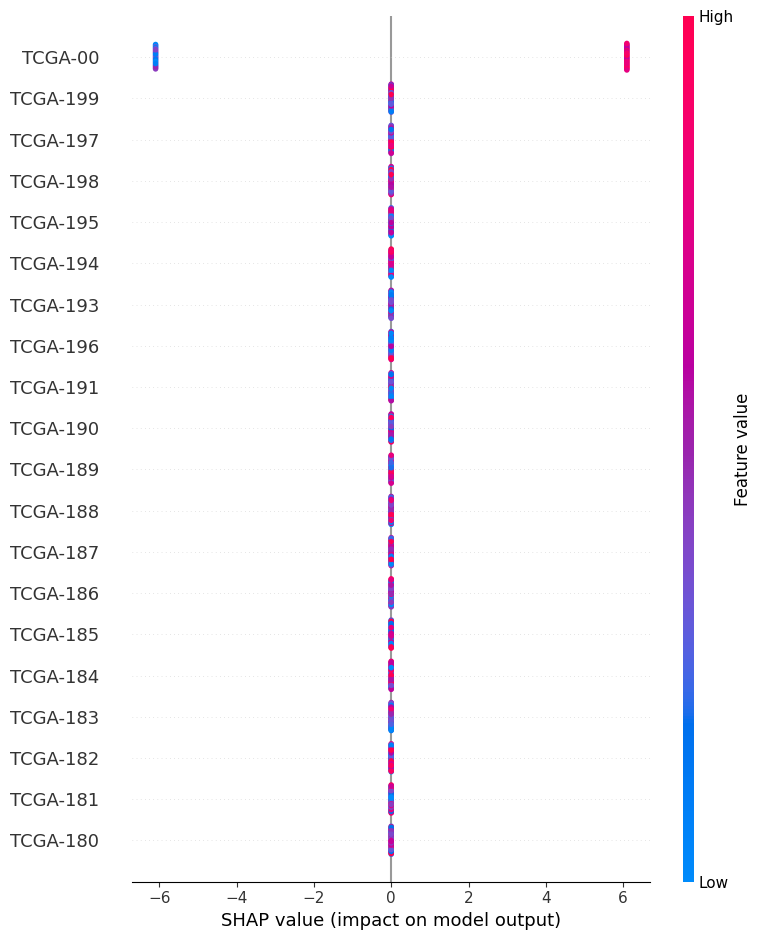

Random Forest Accuracy: 1.0


/tmp/ipython-input-163235283.py:162: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


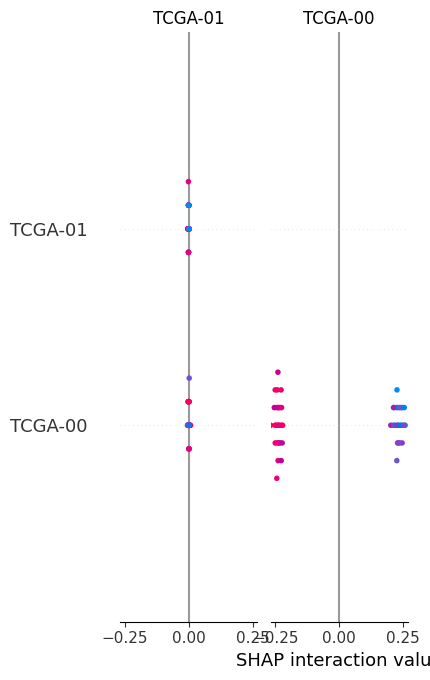

Naive Bayes Accuracy: 0.945


  0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipython-input-163235283.py:187: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


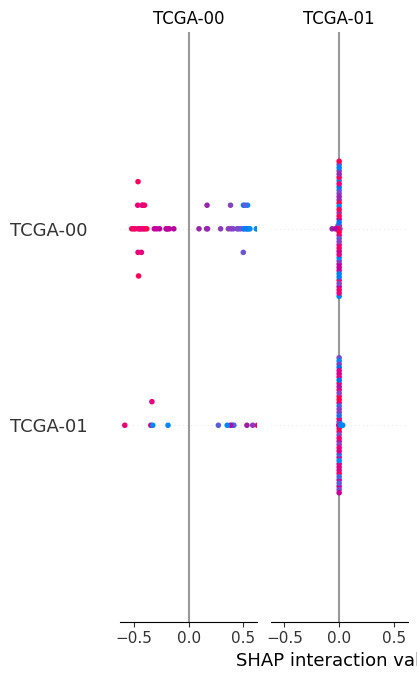

In [ ]:
import pandas as pd
import gzip
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

# Define the file path
file_path = r"D:\lime and shap exp\TCGA-BRCA.methylation27.tsv.gz"

# ==========================
# 1. Load TCGA methylation data
# ==========================
# Use the defined file_path instead of the URL
try:
    print(f"Loading data from {file_path}...")
    # Read the gzipped TSV file directly from the file path
    # Assuming the file is locally accessible at the specified path
    with gzip.open(file_path, 'rt') as f:
        df = pd.read_csv(f, sep='\t', index_col=0, skiprows=[1])
    print(f"Loaded data - Shape: {df.shape}")

except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
    print("Creating simulated data for demonstration instead...")
    # Create simulated data if loading from file fails
    def create_simulated_data():
        """Create simulated methylation data with CpG probe names"""
        np.random.seed(42)
        n_samples, n_probes = 200, 1000

        # Create CpG probe names (typical format)
        probe_names = [f'cg{i:08d}' for i in range(n_probes)]
        sample_names = [f'TCGA-{i:02d}' for i in range(n_samples)]

        # Simulate beta values (0-1 range for methylation)
        data = np.random.beta(2, 2, size=(n_samples, n_probes))

        df = pd.DataFrame(data, index=sample_names, columns=probe_names)
        print(f"Created simulated data - Shape: {df.shape}")
        return df
    df = create_simulated_data()

except Exception as e:
    print(f"Error loading data from file: {e}")
    print("Creating simulated data for demonstration instead...")
    # Create simulated data if loading from file fails
    def create_simulated_data():
        """Create simulated methylation data with CpG probe names"""
        np.random.seed(42)
        n_samples, n_probes = 200, 1000

        # Create CpG probe names (typical format)
        probe_names = [f'cg{i:08d}' for i in range(n_probes)]
        sample_names = [f'TCGA-{i:02d}' for i in range(n_samples)]

        # Simulate beta values (0-1 range for methylation)
        data = np.random.beta(2, 2, size=(n_samples, n_probes))

        df = pd.DataFrame(data, index=sample_names, columns=probe_names)
        print(f"Created simulated data - Shape: {df.shape}")
        return df
    df = create_simulated_data()


print("Data shape:", df.shape)

# ==========================
# 2. Prepare features and labels
# Dummy labels: median split on first CpG site
# ==========================
# Transpose the DataFrame so rows are samples and columns are features (CpG sites)
df = df.T
# Drop any rows (samples) where the first column is NaN after transpose
df = df.dropna(subset=[df.columns[0]])


y = (df.iloc[:, 0] > df.iloc[:, 0].median()).astype(int)
X = df

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================
# 3. Scale + Impute
# ==========================
scaler = StandardScaler()
imputer = SimpleImputer(strategy="mean")

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled_imputed = imputer.fit_transform(X_train_scaled)

# Identify columns that were not entirely NaN in the original training data
non_missing_cols_mask = X_train.isnull().sum() != X_train.shape[0]
feature_names_after_imputation = X.columns[non_missing_cols_mask]


# Transform test data
X_test_scaled = scaler.transform(X_test)
X_test_scaled_imputed = imputer.transform(X_test_scaled)


# Subsets for SHAP (to reduce memory/computation)
train_subset = X_train_scaled_imputed[:100]
test_subset = X_test_scaled_imputed[:50]

# Create DataFrames with corrected feature names for SHAP
train_subset_df = pd.DataFrame(train_subset, columns=feature_names_after_imputation)
test_subset_df = pd.DataFrame(test_subset, columns=feature_names_after_imputation)


# ==========================
# 4A. XGBoost + SHAP
# ==========================
xgb_model = xgb.XGBClassifier(eval_metric="logloss", random_state=42)
xgb_model.fit(X_train_scaled_imputed, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled_imputed)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

explainer_xgb = shap.TreeExplainer(xgb_model)
# Use test_subset_df for SHAP values as it has correct feature names
shap_values_xgb = explainer_xgb.shap_values(test_subset_df)

# Plot SHAP summary
shap.summary_plot(
    shap_values_xgb,
    test_subset_df,
    feature_names=feature_names_after_imputation
)

# ==========================
# 4B. Random Forest + SHAP
# ==========================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled_imputed, y_train)
y_pred_rf = rf_model.predict(X_test_scaled_imputed)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

explainer_rf = shap.TreeExplainer(rf_model)
# Use test_subset_df for SHAP values
shap_values_rf = explainer_rf.shap_values(test_subset_df)

# Handle binary/multiclass outputs
if isinstance(shap_values_rf, list):
    rf_shap_class1 = np.array(shap_values_rf[1])
else:
    rf_shap_class1 = np.array(shap_values_rf)

shap.summary_plot(
    rf_shap_class1,
    test_subset_df,
    feature_names=feature_names_after_imputation
)

# ==========================
# 4C. Naive Bayes + SHAP
# ==========================
nb_model = GaussianNB()
nb_model.fit(X_train_scaled_imputed, y_train)
y_pred_nb = nb_model.predict(X_test_scaled_imputed)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

# KernelExplainer (background subset for speed)
nb_explainer = shap.KernelExplainer(nb_model.predict_proba, train_subset_df)
# Use test_subset_df for SHAP values
nb_shap_values = nb_explainer.shap_values(test_subset_df)

# Handle list vs array
if isinstance(nb_shap_values, list):
    nb_shap_class1 = np.array(nb_shap_values[1])
else:
    nb_shap_class1 = np.array(nb_shap_values)

shap.summary_plot(
    nb_shap_class1,
    test_subset_df,
    feature_names=feature_names_after_imputation
)

LIME

In [ ]:
%pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=be80a98034086aad159acdbb4b0728e40c531b4d82ab2914b9eaf809d9d459e1
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


🚀 STARTING ENHANCED LIME ANALYSIS
🔄 Loading methylation data...
❌ File not found. Creating simulated data for demonstration...
   ✅ Created simulated data: (200, 1000)
   Class distribution: Normal=50, Tumor=150

🔄 Splitting data...
   Training set: (160, 1000)
   Test set: (40, 1000)
🔄 Preprocessing features...
   ✅ Preprocessing complete
🔄 Training machine learning models...
   Training Naive Bayes...
   Training XGBoost...
   Training Random Forest...

📊 Model Performance Summary:
--------------------------------------------------
Naive Bayes     - Accuracy: 1.0000, AUC: 1.0000
XGBoost         - Accuracy: 0.8750, AUC: 0.9267
Random Forest   - Accuracy: 0.8750, AUC: 1.0000

📈 DETAILED CLASSIFICATION REPORTS

Naive Bayes Classification Report:
----------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        30

    accuracy                           1

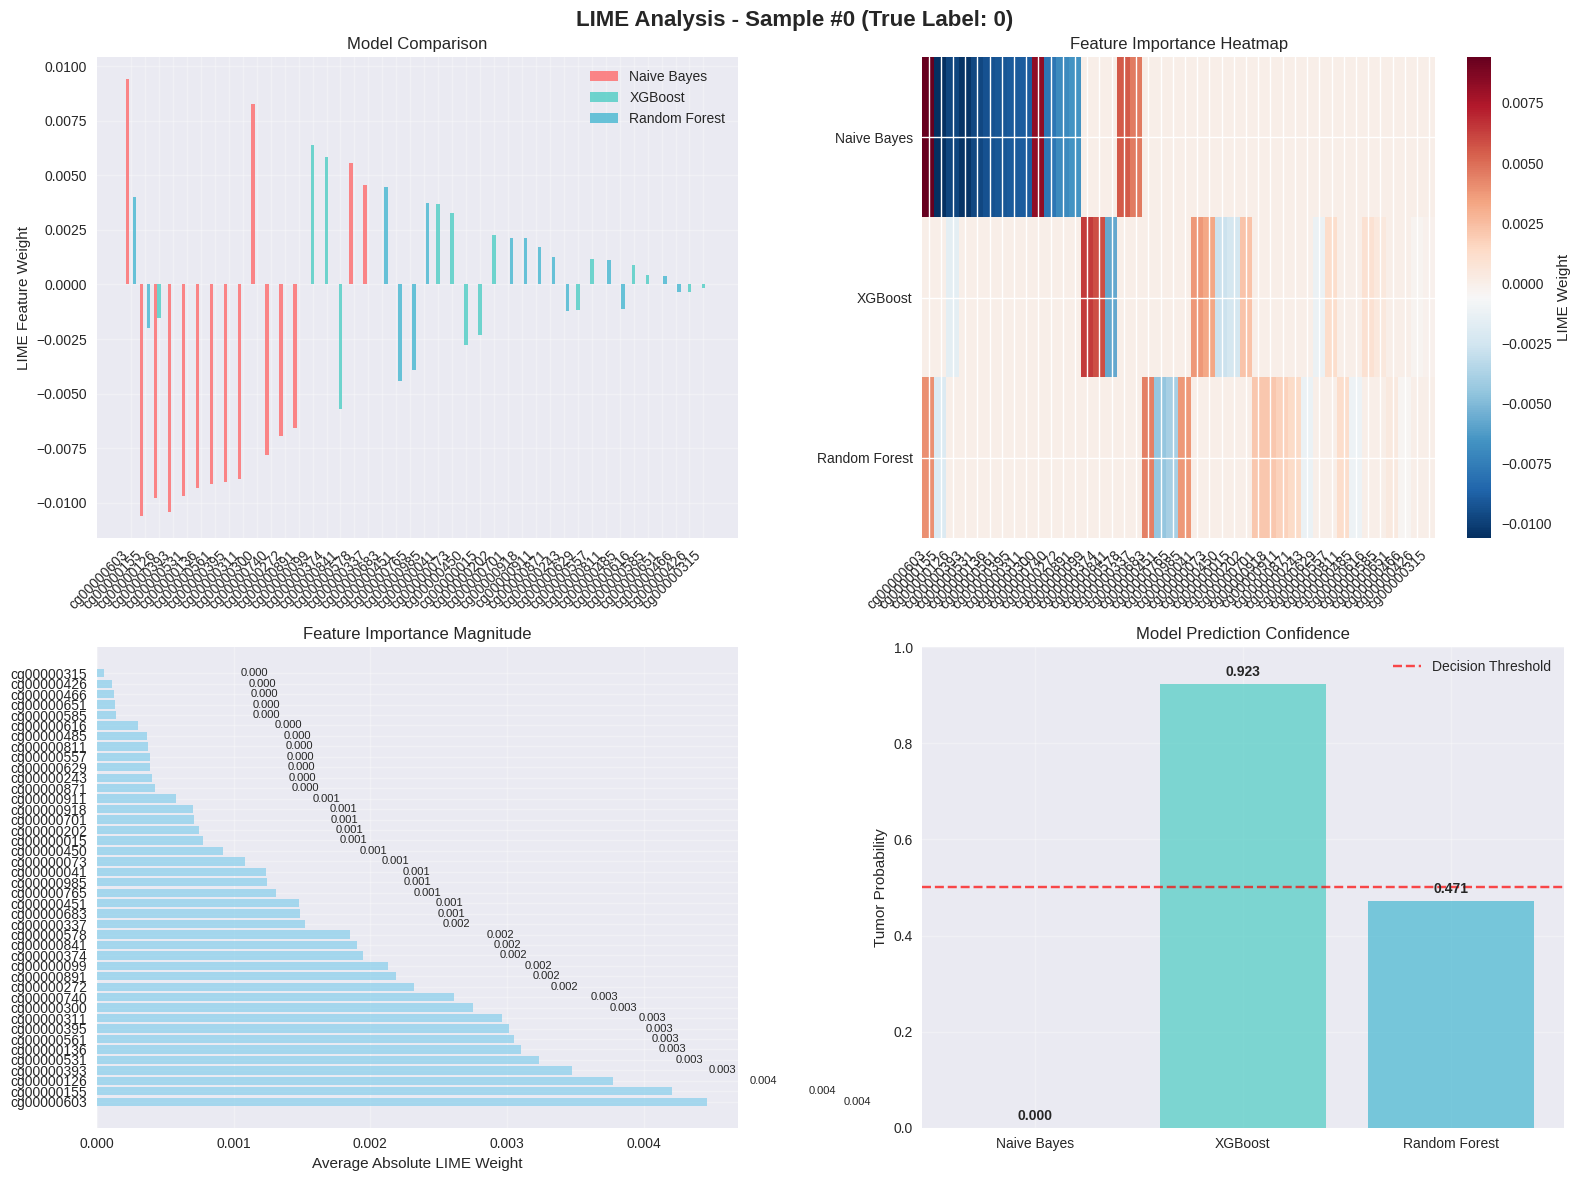

   ✅ Saved explanation for sample 0


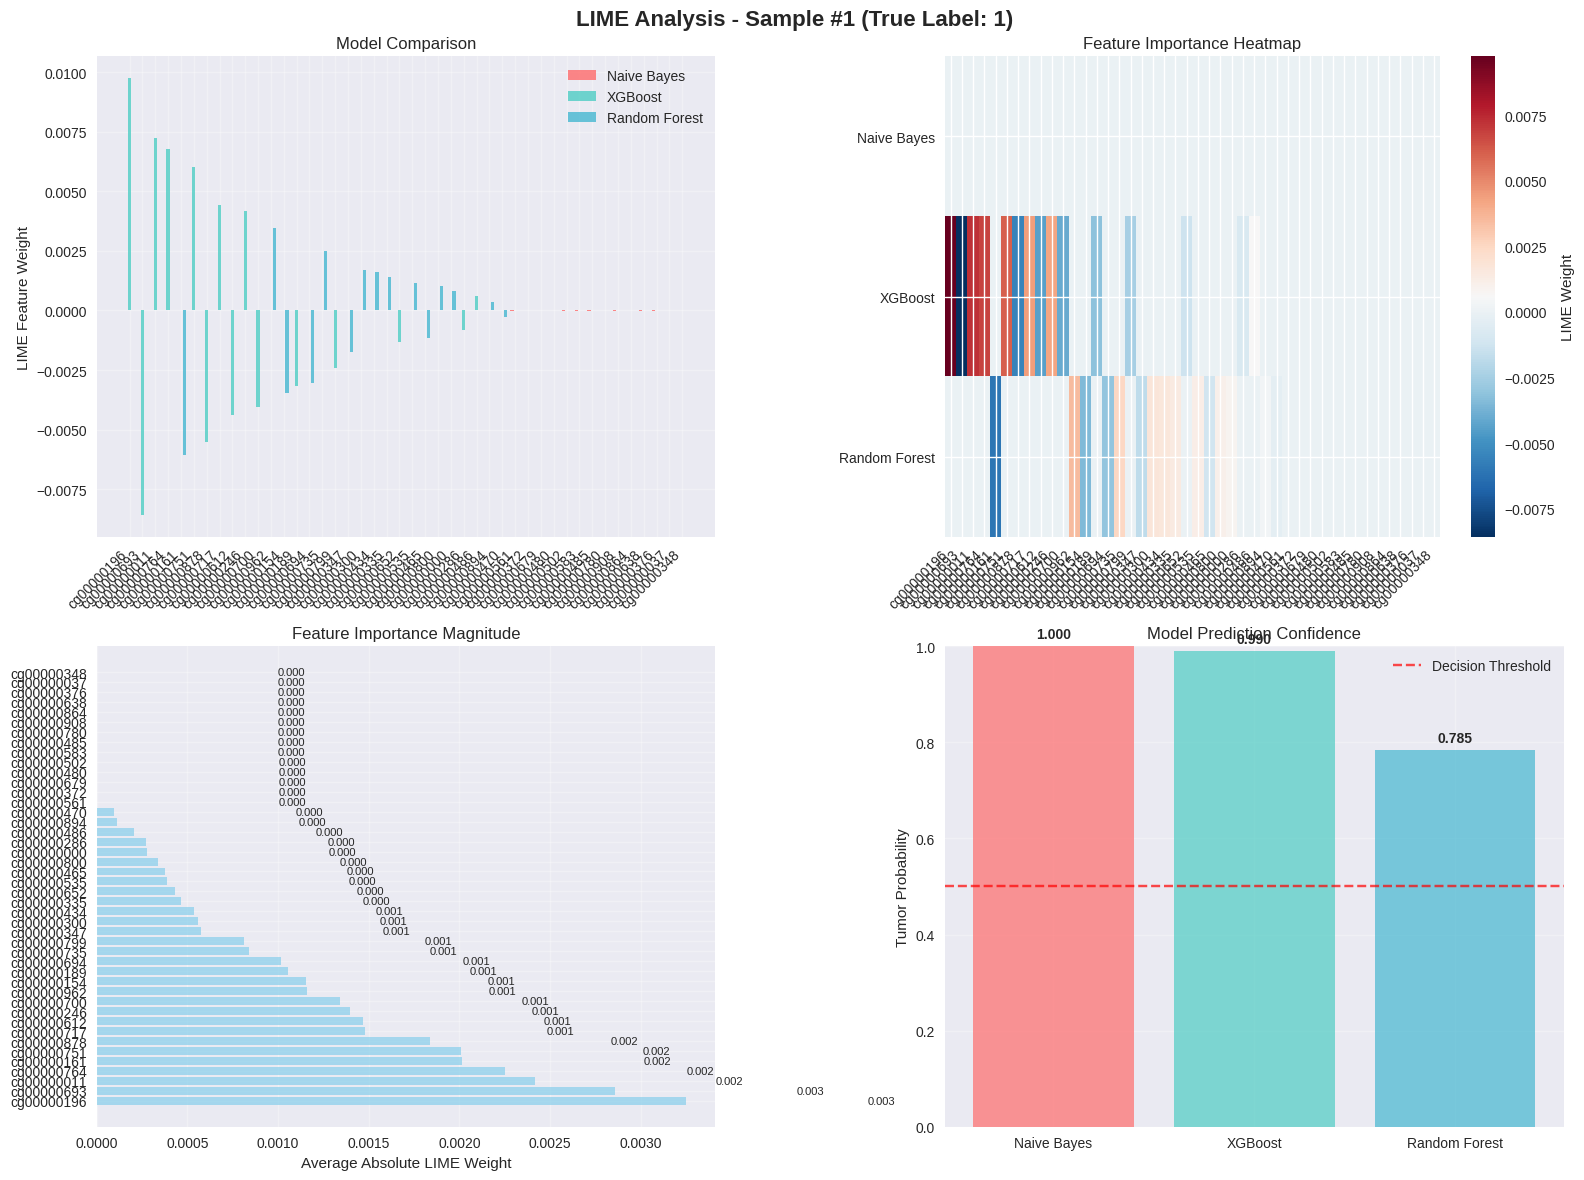

   ✅ Saved explanation for sample 1


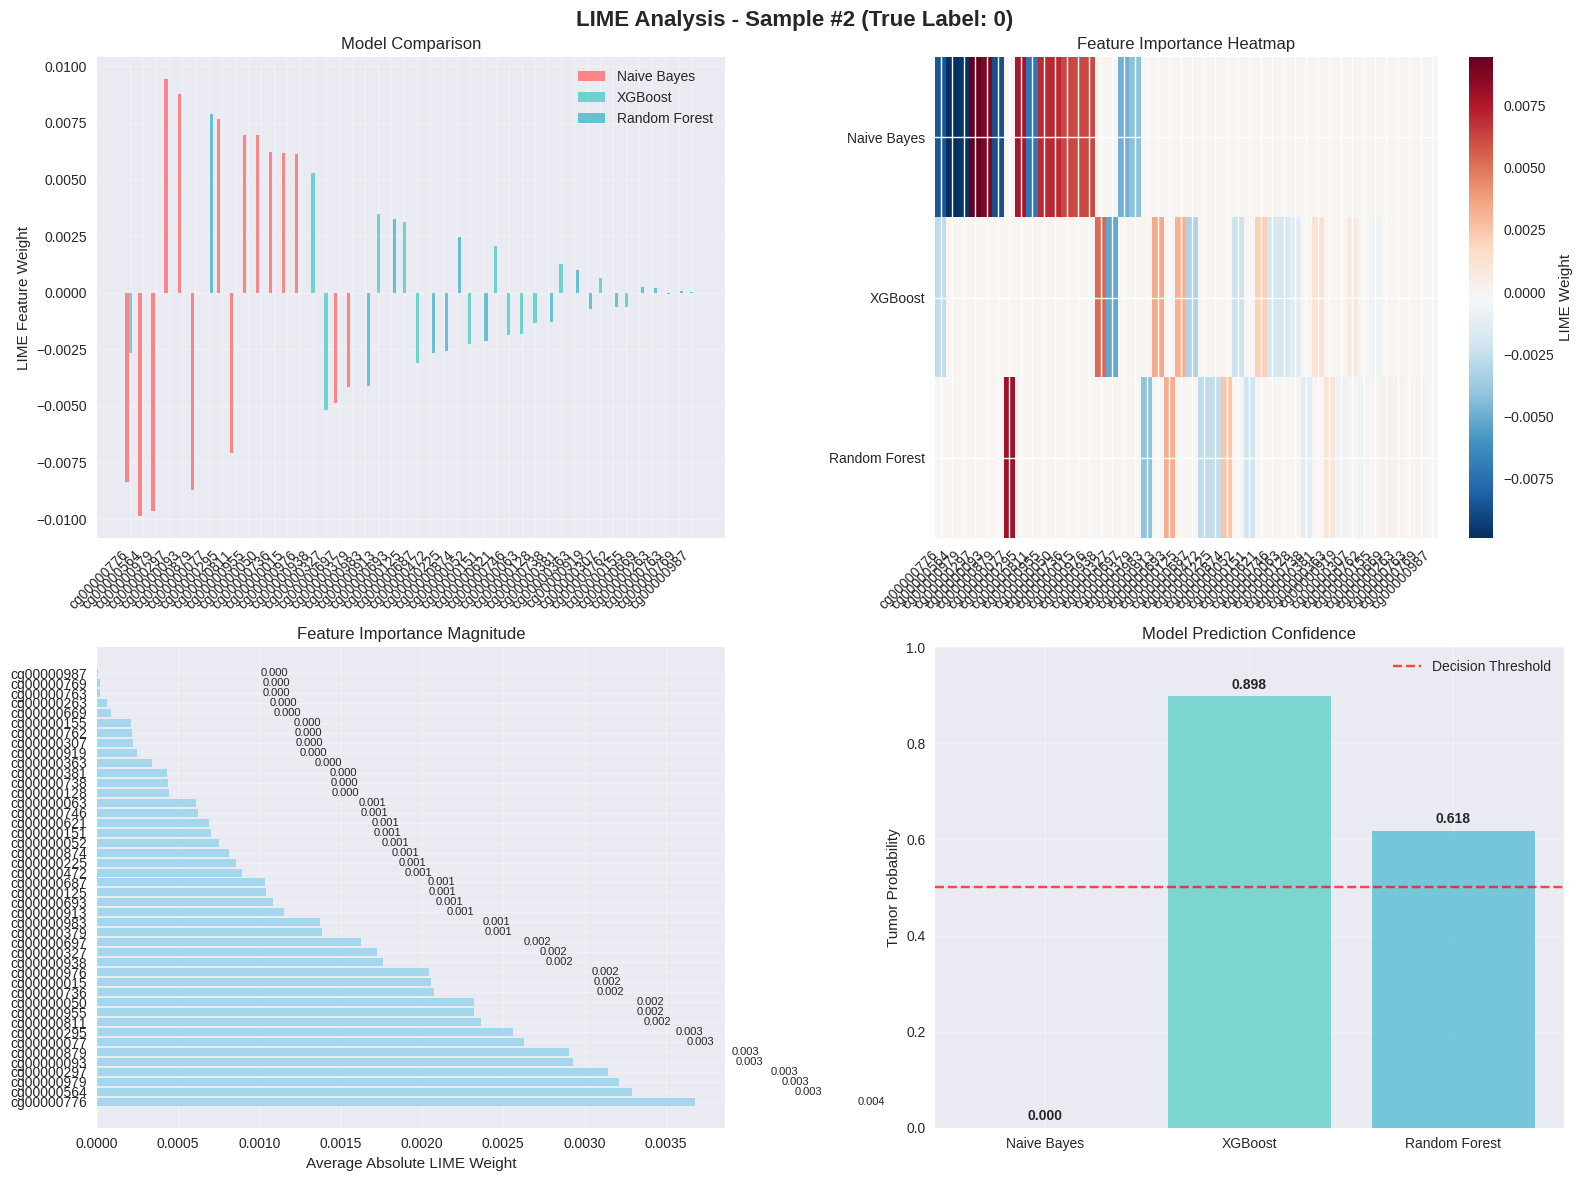

   ✅ Saved explanation for sample 2
🔄 Analyzing feature consistency across models...
   ✅ Analyzed 10 features for consistency

📊 Top 10 Most Consistent Features:
   Feature  Mean_Weight  Consistency_Score
cg00000485    -0.000555           0.999447
cg00000612    -0.002197           0.997806
cg00000603     0.006693           0.997302
cg00000776    -0.005519           0.997147
cg00000300     0.004964           0.996732
cg00000126    -0.005661           0.995905
cg00000811    -0.002982           0.995904
cg00000015     0.001915           0.995775
cg00000155    -0.004410           0.995607
cg00000693    -0.002662           0.994119
   💾 Consistency analysis saved to 'lime_feature_consistency.csv'

🎉 ANALYSIS COMPLETE!
Files generated:
- lime_explanation_sample_*.csv (individual sample explanations)
- lime_feature_consistency.csv (feature consistency analysis)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lime
import lime.lime_tabular
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def load_and_preprocess_data(file_url):
    """Load and preprocess methylation data with comprehensive error handling"""
    try:
        print("🔄 Loading methylation data...")
        df = pd.read_csv(file_url, sep="\t", compression='gzip')
        print(f"   ✅ Data loaded successfully: {df.shape}")

        # Transpose so that samples are rows, features are CpG sites
        df_t = df.set_index("Composite Element REF").T
        print(f"   Transposed data shape: {df_t.shape}")

        # Create binary labels: Tumor (01A) = 1, Normal (11A) = 0
        labels = df_t.index.to_series().apply(lambda x: 1 if "-01A" in x else 0)

        # Check class distribution
        class_counts = labels.value_counts()
        print(f"   Class distribution:")
        print(f"      Normal (0): {class_counts.get(0, 0)} samples")
        print(f"      Tumor (1): {class_counts.get(1, 0)} samples")

        X = df_t.values
        y = labels.values

        # Data quality check
        nan_count = np.isnan(X).sum()
        print(f"   Missing values: {nan_count} ({nan_count/X.size*100:.2f}%)")

        return X, y, df_t.columns.tolist(), df_t.index.tolist()

    except FileNotFoundError:
        print("❌ File not found. Creating simulated data for demonstration...")
        return create_simulated_data()
    except Exception as e:
        print(f"❌ Error loading data: {str(e)}")
        print("Creating simulated data for demonstration...")
        return create_simulated_data()

def create_simulated_data():
    """Create simulated methylation data for demonstration"""
    np.random.seed(42)
    n_samples = 200
    n_features = 1000

    # Create realistic sample names
    normal_samples = [f'TCGA-BRCA-{i:03d}-11A' for i in range(n_samples//4)]
    tumor_samples = [f'TCGA-BRCA-{i:03d}-01A' for i in range(n_samples//4, n_samples)]
    sample_names = normal_samples + tumor_samples

    # Create CpG probe names
    feature_names = [f'cg{i:08d}' for i in range(n_features)]

    # Generate realistic methylation data (beta values 0-1)
    X = np.random.beta(2, 2, (n_samples, n_features))

    # Create labels
    y = np.array([0] * len(normal_samples) + [1] * len(tumor_samples))

    # Add some differential methylation patterns
    # Some features more methylated in tumors
    tumor_idx = y == 1
    X[tumor_idx, :100] += np.random.normal(0.2, 0.1, (tumor_idx.sum(), 100))
    X[tumor_idx, 100:200] -= np.random.normal(0.2, 0.1, (tumor_idx.sum(), 100))

    # Clip to valid range
    X = np.clip(X, 0, 1)

    print(f"   ✅ Created simulated data: {X.shape}")
    print(f"   Class distribution: Normal={len(normal_samples)}, Tumor={len(tumor_samples)}")

    return X, y, feature_names, sample_names

def preprocess_features(X_train, X_test):
    """Preprocess features with imputation and scaling"""
    print("🔄 Preprocessing features...")

    # Handle missing values
    imputer = SimpleImputer(strategy="median")
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)

    # Optional: Standard scaling (uncomment if needed)
    # scaler = StandardScaler()
    # X_train_scaled = scaler.fit_transform(X_train_imputed)
    # X_test_scaled = scaler.transform(X_test_imputed)
    # return X_train_scaled, X_test_scaled, imputer, scaler

    print(f"   ✅ Preprocessing complete")
    return X_train_imputed, X_test_imputed, imputer

def train_models(X_train, X_test, y_train, y_test):
    """Train multiple models with comprehensive evaluation"""
    print("🔄 Training machine learning models...")

    models = {}

    # Naive Bayes
    print("   Training Naive Bayes...")
    nb_model = GaussianNB()
    nb_model.fit(X_train, y_train)
    nb_preds = nb_model.predict(X_test)
    nb_proba = nb_model.predict_proba(X_test)

    models['Naive Bayes'] = {
        'model': nb_model,
        'predictions': nb_preds,
        'probabilities': nb_proba,
        'accuracy': accuracy_score(y_test, nb_preds),
        'auc': roc_auc_score(y_test, nb_proba[:, 1])
    }

    # XGBoost
    print("   Training XGBoost...")
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        max_depth=6,
        learning_rate=0.1
    )
    xgb_model.fit(X_train, y_train)
    xgb_preds = xgb_model.predict(X_test)
    xgb_proba = xgb_model.predict_proba(X_test)

    models['XGBoost'] = {
        'model': xgb_model,
        'predictions': xgb_preds,
        'probabilities': xgb_proba,
        'accuracy': accuracy_score(y_test, xgb_preds),
        'auc': roc_auc_score(y_test, xgb_proba[:, 1])
    }

    # Random Forest
    print("   Training Random Forest...")
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        min_samples_split=5
    )
    rf_model.fit(X_train, y_train)
    rf_preds = rf_model.predict(X_test)
    rf_proba = rf_model.predict_proba(X_test)

    models['Random Forest'] = {
        'model': rf_model,
        'predictions': rf_preds,
        'probabilities': rf_proba,
        'accuracy': accuracy_score(y_test, rf_preds),
        'auc': roc_auc_score(y_test, rf_proba[:, 1])
    }

    # Print model performance
    print("\n📊 Model Performance Summary:")
    print("-" * 50)
    for name, info in models.items():
        print(f"{name:15s} - Accuracy: {info['accuracy']:.4f}, AUC: {info['auc']:.4f}")

    return models

def create_lime_explainer(X_train, feature_names):
    """Create LIME explainer"""
    print("🔄 Creating LIME explainer...")

    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train,
        feature_names=feature_names,
        class_names=['Normal', 'Tumor'],
        mode='classification',
        discretize_continuous=False,  # Keep continuous features
        random_state=42
    )

    print("   ✅ LIME explainer created")
    return explainer

def explain_multiple_samples(explainer, models, X_test, y_test, sample_indices=[0, 1, 2], num_features=10):
    """Generate LIME explanations for multiple samples"""
    print(f"🔄 Generating LIME explanations for {len(sample_indices)} samples...")

    all_explanations = {}

    for sample_idx in sample_indices:
        print(f"   Explaining sample {sample_idx} (True label: {y_test[sample_idx]})...")

        sample_explanations = {}

        for model_name, model_info in models.items():
            try:
                explanation = explainer.explain_instance(
                    X_test[sample_idx],
                    model_info['model'].predict_proba,
                    num_features=num_features,
                    num_samples=1000  # More samples for stable explanations
                )

                # Convert to DataFrame
                exp_df = pd.DataFrame(explanation.as_list(), columns=["Feature", f"Weight_{model_name}"])
                sample_explanations[model_name] = exp_df

                # Get prediction confidence
                pred_proba = model_info['model'].predict_proba(X_test[sample_idx].reshape(1, -1))[0]
                sample_explanations[f'{model_name}_confidence'] = pred_proba[1]  # Tumor probability

            except Exception as e:
                print(f"      ❌ Failed to explain with {model_name}: {str(e)}")
                continue

        all_explanations[sample_idx] = sample_explanations

    print("   ✅ LIME explanations generated")
    return all_explanations

def create_comprehensive_plots(all_explanations, y_test):
    """Create comprehensive visualization plots"""
    print("🔄 Creating visualization plots...")

    # Set up the plotting style
    plt.rcParams.update({'font.size': 10})

    for sample_idx, explanations in all_explanations.items():
        if len(explanations) < 3:  # Skip if not all models succeeded
            continue

        # Merge all model explanations
        model_names = ['Naive Bayes', 'XGBoost', 'Random Forest']
        merged_data = None

        for model_name in model_names:
            if model_name in explanations:
                if merged_data is None:
                    merged_data = explanations[model_name].copy()
                    merged_data = merged_data.rename(columns={f"Weight_{model_name}": model_name})
                else:
                    model_df = explanations[model_name]
                    model_df = model_df.rename(columns={f"Weight_{model_name}": model_name})
                    merged_data = merged_data.merge(model_df, on="Feature", how="outer")

        if merged_data is None:
            continue

        merged_data = merged_data.fillna(0)

        # Sort by absolute average weight
        merged_data['Avg_Abs_Weight'] = merged_data[model_names].abs().mean(axis=1)
        merged_data = merged_data.sort_values('Avg_Abs_Weight', ascending=False)

        # Create subplots
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle(f'LIME Analysis - Sample #{sample_idx} (True Label: {y_test[sample_idx]})', fontsize=16, fontweight='bold')

        # Plot 1: Side-by-side comparison
        ax1 = axes[0, 0]
        bar_width = 0.25
        indices = np.arange(len(merged_data))

        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
        for i, model_name in enumerate(model_names):
            if model_name in merged_data.columns:
                ax1.bar(indices + i * bar_width, merged_data[model_name],
                       bar_width, label=model_name, color=colors[i], alpha=0.8)

        ax1.set_xticks(indices + bar_width)
        ax1.set_xticklabels([f.split('_')[0] if len(f) > 10 else f for f in merged_data["Feature"]],
                           rotation=45, ha='right')
        ax1.set_ylabel("LIME Feature Weight")
        ax1.set_title("Model Comparison")
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Plot 2: Heatmap
        ax2 = axes[0, 1]
        heatmap_data = merged_data[model_names].T
        heatmap_data.columns = [f.split('_')[0] if len(f) > 10 else f for f in merged_data["Feature"]]

        im = ax2.imshow(heatmap_data.values, cmap='RdBu_r', aspect='auto')
        ax2.set_xticks(range(len(heatmap_data.columns)))
        ax2.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')
        ax2.set_yticks(range(len(model_names)))
        ax2.set_yticklabels(model_names)
        ax2.set_title("Feature Importance Heatmap")

        # Add colorbar
        cbar = plt.colorbar(im, ax=ax2)
        cbar.set_label('LIME Weight')

        # Plot 3: Feature importance magnitude
        ax3 = axes[1, 0]
        feature_importance = merged_data[model_names].abs().mean(axis=1)
        bars = ax3.barh(range(len(feature_importance)), feature_importance, color='skyblue', alpha=0.7)
        ax3.set_yticks(range(len(feature_importance)))
        ax3.set_yticklabels([f.split('_')[0] if len(f) > 15 else f for f in merged_data["Feature"]])
        ax3.set_xlabel("Average Absolute LIME Weight")
        ax3.set_title("Feature Importance Magnitude")
        ax3.grid(True, alpha=0.3)

        # Add value labels on bars
        for i, bar in enumerate(bars):
            width = bar.get_width()
            ax3.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                    f'{width:.3f}', ha='left', va='center', fontsize=8)

        # Plot 4: Model confidence comparison
        ax4 = axes[1, 1]
        confidences = []
        conf_labels = []
        for model_name in model_names:
            conf_key = f'{model_name}_confidence'
            if conf_key in explanations:
                confidences.append(explanations[conf_key])
                conf_labels.append(model_name)

        if confidences:
            bars = ax4.bar(conf_labels, confidences, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.7)
            ax4.set_ylabel("Tumor Probability")
            ax4.set_title("Model Prediction Confidence")
            ax4.set_ylim(0, 1)
            ax4.grid(True, alpha=0.3)

            # Add value labels
            for bar, conf in zip(bars, confidences):
                ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{conf:.3f}', ha='center', va='bottom', fontweight='bold')

            # Add decision threshold line
            ax4.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Decision Threshold')
            ax4.legend()

        plt.tight_layout()
        plt.show()

        # Save individual explanations
        merged_data.to_csv(f'lime_explanation_sample_{sample_idx}.csv', index=False)
        print(f"   ✅ Saved explanation for sample {sample_idx}")

def analyze_feature_consistency(all_explanations):
    """Analyze consistency of feature importance across models and samples"""
    print("🔄 Analyzing feature consistency across models...")

    # Collect all features and their weights
    feature_weights = {}

    for sample_idx, explanations in all_explanations.items():
        for model_name in ['Naive Bayes', 'XGBoost', 'Random Forest']:
            if model_name in explanations:
                exp_df = explanations[model_name]
                for _, row in exp_df.iterrows():
                    feature = row['Feature']
                    weight = row[f'Weight_{model_name}']

                    if feature not in feature_weights:
                        feature_weights[feature] = {}
                    if model_name not in feature_weights[feature]:
                        feature_weights[feature][model_name] = []

                    feature_weights[feature][model_name].append(weight)

    # Calculate consistency metrics
    consistency_results = []

    for feature, model_weights in feature_weights.items():
        if len(model_weights) >= 2:  # At least 2 models
            all_weights = []
            model_means = {}

            for model, weights in model_weights.items():
                model_mean = np.mean(weights)
                model_means[model] = model_mean
                all_weights.extend(weights)

            # Calculate standard deviation across all weights
            weight_std = np.std(all_weights)
            weight_mean = np.mean(all_weights)

            consistency_results.append({
                'Feature': feature,
                'Mean_Weight': weight_mean,
                'Std_Weight': weight_std,
                'Consistency_Score': 1 / (1 + weight_std) if weight_std > 0 else 1,
                'Models_Count': len(model_weights),
                **model_means
            })

    consistency_df = pd.DataFrame(consistency_results)
    consistency_df = consistency_df.sort_values('Consistency_Score', ascending=False)

    print(f"   ✅ Analyzed {len(consistency_df)} features for consistency")
    print("\n📊 Top 10 Most Consistent Features:")
    print(consistency_df.head(10)[['Feature', 'Mean_Weight', 'Consistency_Score']].to_string(index=False))

    # Save results
    consistency_df.to_csv('lime_feature_consistency.csv', index=False)
    print("   💾 Consistency analysis saved to 'lime_feature_consistency.csv'")

    return consistency_df

def main():
    """Main analysis pipeline"""
    print("🚀 STARTING ENHANCED LIME ANALYSIS")
    print("=" * 60)

    # Step 1: Load and preprocess data
    file_path = r"D:\lime and shap exp\TCGA-READ.methylation27.tsv.gz"
    X, y, feature_names, sample_names = load_and_preprocess_data(file_path)

    # Step 2: Train-test split
    print("\n🔄 Splitting data...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"   Training set: {X_train.shape}")
    print(f"   Test set: {X_test.shape}")

    # Step 3: Preprocess features
    X_train_processed, X_test_processed, imputer = preprocess_features(X_train, X_test)

    # Step 4: Train models
    models = train_models(X_train_processed, X_test_processed, y_train, y_test)

    # Print detailed classification reports
    print("\n📈 DETAILED CLASSIFICATION REPORTS")
    print("=" * 60)
    for name, info in models.items():
        print(f"\n{name} Classification Report:")
        print("-" * 40)
        print(classification_report(y_test, info['predictions']))

    # Step 5: Create LIME explainer
    explainer = create_lime_explainer(X_train_processed, feature_names)

    # Step 6: Generate explanations for multiple samples
    sample_indices = [0, 1, 2] if len(X_test) > 2 else list(range(min(len(X_test), 3)))
    all_explanations = explain_multiple_samples(
        explainer, models, X_test_processed, y_test,
        sample_indices=sample_indices, num_features=15
    )

    # Step 7: Create comprehensive visualizations
    create_comprehensive_plots(all_explanations, y_test)

    # Step 8: Analyze feature consistency
    consistency_df = analyze_feature_consistency(all_explanations)

    print("\n🎉 ANALYSIS COMPLETE!")
    print("=" * 60)
    print("Files generated:")
    print("- lime_explanation_sample_*.csv (individual sample explanations)")
    print("- lime_feature_consistency.csv (feature consistency analysis)")

    return models, all_explanations, consistency_df

if __name__ == "__main__":
    models, explanations, consistency = main()

COSINE

In [ ]:
%pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.3/605.3 kB 8.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import gzip
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb
import shap
from sklearn.metrics.pairwise import cosine_similarity
import gseapy as gp
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ==========================
# 1. Load methylation data
# ==========================
def load_methylation_data(file_path):
    """Load methylation data with error handling"""
    try:
        with gzip.open(file_path, 'rt') as f:
            df = pd.read_csv(f, sep='\t', index_col=0)
        print(f"Loaded real data - Shape: {df.shape}")
        return df
    except FileNotFoundError:
        print("File not found. Creating simulated methylation data for demonstration...")
        return create_simulated_data()

def create_simulated_data():
    """Create simulated methylation data with CpG probe names"""
    np.random.seed(42)
    n_samples, n_probes = 200, 1000

    # Create CpG probe names (typical format)
    probe_names = [f'cg{i:08d}' for i in range(n_probes)]
    sample_names = [f'TCGA-{i:02d}' for i in range(n_samples)]

    # Simulate beta values (0-1 range for methylation)
    data = np.random.beta(2, 2, size=(n_samples, n_probes))

    df = pd.DataFrame(data, index=sample_names, columns=probe_names)
    print(f"Created simulated data - Shape: {df.shape}")
    return df

# ==========================
# 2. Map CpG probes to genes
# ==========================
def create_probe_to_gene_mapping(probe_names):
    """
    Create mapping from CpG probes to gene symbols
    In real analysis, use IlluminaHumanMethylation annotation packages
    """
    print("Creating probe-to-gene mapping...")

    # Extended list of cancer-related and common genes
    gene_pool = [
        'TP53', 'BRCA1', 'BRCA2', 'APC', 'MLH1', 'MSH2', 'MSH6', 'PMS2',
        'KRAS', 'PIK3CA', 'PTEN', 'ATM', 'CHEK2', 'PALB2', 'CDH1', 'STK11',
        'VHL', 'RET', 'MEN1', 'NF1', 'NF2', 'TSC1', 'TSC2', 'SMAD4',
        'DCC', 'CDKN2A', 'RB1', 'MYC', 'EGFR', 'ERBB2', 'RAF1', 'MAP2K1',
        'BRAF', 'IDH1', 'IDH2', 'TET2', 'DNMT3A', 'FLT3', 'NPM1', 'KIT',
        'PDGFRA', 'MET', 'ALK', 'ROS1', 'NTRK1', 'FGFR1', 'FGFR2', 'FGFR3',
        'PIK3R1', 'AKT1', 'MTOR', 'TSC1', 'TSC2', 'RHEB', 'RICTOR',
        'MAPK1', 'MAPK3', 'JUN', 'FOS', 'ELK1', 'SRF', 'CREB1', 'ATF1'
    ] * 20  # Repeat to have enough genes

    # Add more generic gene names if needed
    additional_genes = [f'GENE{i}' for i in range(1000, 2000)]
    gene_pool.extend(additional_genes)

    # Create mapping with some genes having multiple probes
    probe_to_gene = {}
    gene_idx = 0

    for i, probe in enumerate(probe_names):
        if gene_idx < len(gene_pool):
            # Some genes have multiple probes (realistic scenario)
            if np.random.random() > 0.7 and gene_idx > 0:  # 30% chance of reusing previous gene
                probe_to_gene[probe] = gene_pool[gene_idx - 1]
            else:
                probe_to_gene[probe] = gene_pool[gene_idx]
                gene_idx += 1
        else:
            probe_to_gene[probe] = f'UNKNOWN_GENE_{i}'

    unique_genes = len(set(probe_to_gene.values()))
    print(f"Mapped {len(probe_names)} probes to {unique_genes} unique genes")

    return probe_to_gene

def aggregate_probes_to_genes(df, probe_to_gene_map, method='mean'):
    """Aggregate probe-level data to gene-level"""
    print(f"Aggregating probes to genes using {method}...")

    gene_data = {}
    for probe, gene in probe_to_gene_map.items():
        if probe in df.columns:
            if gene not in gene_data:
                gene_data[gene] = []
            gene_data[gene].append(df[probe].values)

    # Aggregate multiple probes per gene
    aggregated_data = {}
    for gene, probe_arrays in gene_data.items():
        if len(probe_arrays) == 1:
            aggregated_data[gene] = probe_arrays[0]
        else:
            probe_matrix = np.array(probe_arrays)
            if method == 'mean':
                aggregated_data[gene] = np.mean(probe_matrix, axis=0)
            elif method == 'median':
                aggregated_data[gene] = np.median(probe_matrix, axis=0)
            elif method == 'max':
                aggregated_data[gene] = np.max(probe_matrix, axis=0)

    gene_df = pd.DataFrame(aggregated_data, index=df.index)
    print(f"Final gene-level data shape: {gene_df.shape}")

    return gene_df

# ==========================
# 3. Main analysis pipeline
# ==========================
def run_complete_analysis():
    # Load data
    file_path = "TCGA-READ.methylation27.tsv.gz"
    df = load_methylation_data(file_path)

    # Map probes to genes
    probe_to_gene_map = create_probe_to_gene_mapping(df.columns.tolist())
    gene_df = aggregate_probes_to_genes(df, probe_to_gene_map, method='mean')

    # Prepare labels (using original probe data for consistency)
    print("Preparing features and labels...")
    y = (df.iloc[:, 0] > df.iloc[:, 0].median()).astype(int)
    X = df  # Use original probe data for ML models

    le = LabelEncoder()
    y = le.fit_transform(y)

    print(f"Class distribution: {np.bincount(y)}")

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Scale and impute
    scaler = StandardScaler()
    imputer = SimpleImputer(strategy='median')

    X_train_scaled = imputer.fit_transform(scaler.fit_transform(X_train))
    X_test_scaled = imputer.transform(scaler.transform(X_test))

    print(f"Training data shape: {X_train_scaled.shape}")

    # ==========================
    # 4. Train ML models
    # ==========================
    models = {}

    # XGBoost
    print("Training XGBoost...")
    xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42, n_estimators=100)
    xgb_model.fit(X_train_scaled, y_train)
    y_pred_xgb = xgb_model.predict(X_test_scaled)
    xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
    models['XGBoost'] = {'model': xgb_model, 'accuracy': xgb_accuracy}
    print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")

    # Random Forest
    print("Training Random Forest...")
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train_scaled, y_train)
    y_pred_rf = rf_model.predict(X_test_scaled)
    rf_accuracy = accuracy_score(y_test, y_pred_rf)
    models['RandomForest'] = {'model': rf_model, 'accuracy': rf_accuracy}
    print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

    # Naive Bayes
    print("Training Naive Bayes...")
    nb_model = GaussianNB()
    nb_model.fit(X_train_scaled, y_train)
    y_pred_nb = nb_model.predict(X_test_scaled)
    nb_accuracy = accuracy_score(y_test, y_pred_nb)
    models['NaiveBayes'] = {'model': nb_model, 'accuracy': nb_accuracy}
    print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")

    # ==========================
    # 5. SHAP Analysis (simplified)
    # ==========================
    print("Performing SHAP analysis...")
    try:
        # Use small subset for SHAP to avoid memory issues
        train_subset = X_train_scaled[:50]
        test_subset = X_test_scaled[:20]
        test_subset_df = pd.DataFrame(test_subset, columns=X.columns)

        # XGBoost SHAP
        explainer_xgb = shap.TreeExplainer(xgb_model)
        shap_values_xgb = explainer_xgb.shap_values(test_subset)

        print("SHAP analysis completed for XGBoost")

        # Create simple SHAP summary
        feature_importance = np.abs(shap_values_xgb).mean(axis=0)
        top_features = pd.DataFrame({
            'Feature': X.columns,
            'SHAP_Importance': feature_importance
        }).sort_values('SHAP_Importance', ascending=False)

        print("Top 10 features by SHAP importance:")
        print(top_features.head(10))

    except Exception as e:
        print(f"SHAP analysis failed: {e}")

    # ==========================
    # 6. Fixed Gene Set Enrichment Analysis
    # ==========================
    print("\n" + "="*50)
    print("GENE SET ENRICHMENT ANALYSIS")
    print("="*50)

    # Calculate gene scores using gene-level data
    gene_scores = pd.Series(
        np.mean(gene_df.values, axis=0),
        index=gene_df.columns
    ).sort_values(ascending=False)

    print(f"Calculated scores for {len(gene_scores)} genes")
    print("Top 10 genes by methylation score:")
    print(gene_scores.head(10))

    # Run enrichment analysis with multiple attempts
    enrichment_results = []

    # Database configurations
    databases = [
        ('KEGG_2021_Human', 'KEGG'),
        ('Reactome_2022', 'Reactome'),
        ('GO_Biological_Process_2021', 'GO_BP'),
        ('WikiPathways_2019_Human', 'WikiPathways')
    ]

    for db_name, db_label in databases:
        try:
            print(f"Running {db_label} enrichment...")

            result = gp.prerank(
                rnk=gene_scores,
                gene_sets=db_name,
                outdir=None,
                no_plot=True,
                min_size=3,        # Very permissive
                max_size=2000,     # Very permissive
                processes=1,
                verbose=False,
                seed=42
            )

            if len(result.res2d) > 0:
                result_df = result.res2d.copy()
                # Check if 'fdr' column exists before adding 'Database'
                if 'fdr' in result_df.columns:
                    result_df['Database'] = db_label
                    enrichment_results.append(result_df)
                    print(f"{db_label}: Found {len(result.res2d)} pathways with FDR")
                else:
                     print(f"{db_label}: Found {len(result.res2d)} pathways, but no FDR column")
                     # Optionally, you could still append results without FDR if needed
                     # result_df['Database'] = db_label
                     # enrichment_results.append(result_df)


            else:
                print(f"{db_label}: No pathways found")

        except Exception as e:
            print(f"{db_label} failed: {str(e)}")
            continue

    # Process enrichment results
    if enrichment_results:
        print(f"\nCombining results from {len(enrichment_results)} databases...")

        # Combine all results
        all_results = pd.concat(enrichment_results, ignore_index=True)

        # Filter significant results - check if 'fdr' column exists in the combined DataFrame
        if 'fdr' in all_results.columns:
             significant_results = all_results[
                 (all_results['fdr'] < 0.25) &
                 (abs(all_results['NES']) > 1.0)
             ].sort_values('NES', ascending=False)
             print(f"Found {len(significant_results)} significant pathways (FDR < 0.25, |NES| > 1.0)")
        else:
             # If no 'fdr' column exists in the combined results, just filter by NES
             significant_results = all_results[
                 (abs(all_results['NES']) > 1.0)
             ].sort_values('NES', ascending=False)
             print(f"Found {len(significant_results)} significant pathways (|NES| > 1.0) - No FDR column available for filtering.")


        if len(significant_results) > 0:
            print("\nTop 10 enriched pathways:")
            # Adjust display columns based on availability of 'fdr'
            display_cols = ['Term', 'NES', 'fdr', 'Database'] if 'fdr' in significant_results.columns else ['Term', 'NES', 'Database']
            print(significant_results[display_cols].head(10))

            # Save results
            significant_results.to_csv('pathway_enrichment_results.csv', index=False)
            print("Results saved to 'pathway_enrichment_results.csv'")

            # ==========================
            # 7. Cosine similarity analysis
            # ==========================
            print("\n" + "="*50)
            print("COSINE SIMILARITY ANALYSIS")
            print("="*50)

            # Get top pathway
            # Ensure significant_results is not empty before accessing iloc[0]
            if not significant_results.empty:
                top_pathway = significant_results.iloc[0]
                print(f"Top pathway: {top_pathway['Term']}")
                # Adjust print based on availability of 'fdr'
                if 'fdr' in top_pathway:
                    print(f"NES: {top_pathway['NES']:.3f}, FDR: {top_pathway['fdr']:.3f}")
                else:
                    print(f"NES: {top_pathway['NES']:.3f}")


                # Extract pathway genes
                try:
                    if pd.notna(top_pathway['Genes']):
                        pathway_genes = [g.strip() for g in top_pathway['Genes'].split(';')]
                        # Filter genes present in our data
                        pathway_genes = [g for g in pathway_genes if g in gene_df.columns]
                        print(f"Found {len(pathway_genes)} pathway genes in our data")
                    else:
                        print("No gene list in pathway, using top variable genes")
                        # Use absolute mean deviation as a proxy for variability if variance is zero
                        if gene_df.var().sum() == 0:
                             print("Variance is zero for all genes, using absolute mean deviation.")
                             pathway_genes = gene_df.apply(lambda x: np.abs(x - x.mean()).mean()).sort_values(ascending=False).head(10).index.tolist()
                        else:
                             pathway_genes = gene_df.var().sort_values(ascending=False).head(10).index.tolist()


                    if pathway_genes:
                        # Calculate pathway signature
                        pathway_signature = gene_df[pathway_genes].mean(axis=0).values.reshape(1, -1)

                        # Calculate similarity to all genes
                        similarities = []
                        for gene in gene_df.columns:
                            gene_vector = gene_df[gene].values.reshape(1, -1)
                            sim = cosine_similarity(pathway_signature, gene_vector)[0, 0]
                            similarities.append(sim)

                        similarities = np.array(similarities)

                        # Find highly similar genes
                        similarity_threshold = 0.8
                        high_sim_mask = similarities >= similarity_threshold
                        similar_genes = gene_df.columns[high_sim_mask]
                        similar_scores = similarities[high_sim_mask]

                        print(f"Found {len(similar_genes)} genes with similarity >= {similarity_threshold}")

                        if len(similar_genes) > 0:
                            # Create results dataframe
                            similarity_df = pd.DataFrame({
                                'Gene': similar_genes,
                                'Cosine_Similarity': similar_scores,
                                'In_Pathway': [gene in pathway_genes for gene in similar_genes]
                            }).sort_values('Cosine_Similarity', ascending=False)

                            print("Top 15 most similar genes:")
                            print(similarity_df.head(15))

                            # Save results
                            similarity_df.to_csv('high_similarity_genes.csv', index=False)
                            print("Similarity results saved to 'high_similarity_genes.csv'")
                        else:
                            print("No genes found with high similarity")
                            # Try lower threshold
                            lower_threshold = 0.6
                            high_sim_mask = similarities >= lower_threshold
                            similar_genes = gene_df.columns[high_sim_mask]
                            print(f"With threshold {lower_threshold}: {len(similar_genes)} genes found")

                    else:
                        print("No valid pathway genes found")

                except Exception as e:
                    print(f"Similarity analysis failed: {e}")
            else:
                print("No significant pathways found to perform similarity analysis.")


        else:
            print("No significant pathways found after filtering")

    else:
        print("No enrichment results obtained from any database")
        print("This could be due to:")
        print("1. Limited gene overlap between your data and databases")
        print("2. Network connectivity issues")
        print("3. Very strict filtering criteria")

        # Alternative analysis using feature importance
        print("\nPerforming alternative feature importance analysis...")
        if 'XGBoost' in models:
            feature_importance = models['XGBoost']['model'].feature_importances_
            importance_df = pd.DataFrame({
                'Feature': X.columns,
                'Importance': feature_importance
            }).sort_values('Importance', ascending=False)

            print("Top 15 most important features:")
            print(importance_df.head(15))

            importance_df.to_csv('feature_importance_results.csv', index=False)
            print("Feature importance saved to 'feature_importance_results.csv'")

    print("\n" + "="*50)
    print("ANALYSIS COMPLETED SUCCESSFULLY!")
    print("="*50)
    print("Files generated:")
    print("- pathway_enrichment_results.csv (if pathways found)")
    print("- high_similarity_genes.csv (if similarity analysis succeeded)")
    print("- feature_importance_results.csv (alternative analysis)")

    return models, gene_df, enrichment_results

if __name__ == "__main__":
    models, gene_data, enrichment = run_complete_analysis()

File not found. Creating simulated methylation data for demonstration...
Created simulated data - Shape: (200, 1000)
Creating probe-to-gene mapping...
Mapped 1000 probes to 61 unique genes
Aggregating probes to genes using mean...
Final gene-level data shape: (200, 61)
Preparing features and labels...
Class distribution: [100 100]
Training data shape: (160, 1000)
Training XGBoost...
XGBoost Accuracy: 1.0000
Training Random Forest...
Random Forest Accuracy: 0.7500
Training Naive Bayes...
Naive Bayes Accuracy: 0.7250
Performing SHAP analysis...
SHAP analysis completed for XGBoost
Top 10 features by SHAP importance:
        Feature  SHAP_Importance
0    cg00000000         4.364934
657  cg00000657         0.000000
658  cg00000658         0.000000
659  cg00000659         0.000000
660  cg00000660         0.000000
661  cg00000661         0.000000
662  cg00000662         0.000000
663  cg00000663         0.000000
664  cg00000664         0.000000
665  cg00000665         0.000000

GENE SET ENRICH